# Phase 1 — Preparing a 2D Antiferromagnet on a Rydberg Array

**Goal:** We simulate a square array of interacting Rydberg atoms and drive it across a quantum phase transition from a disordered paramagnet into a checkerboard antiferromagnet. We further reproduce the core of Scholl et al., *Nature* 595 (2021).

## Physical idea
Pasqal's neutral atom quantum computing uses Rb atoms (trapped in optical tweezers) as qubits. These can then be strongly excited by a laser to a Rydberg state, significantly increasing the radius of the atoms and the interaction between neighbouring atoms. The Rydberg atoms thus satisfy the requirement for qubit gates, while ground state atoms are virtually non-interacting and remain coherent for storing information. 

Hence, each atom acts as an effective spin-1/2 system:
- ground state = spin down
- Rydberg state = spin up

The global laser drive `Omega` competes with Rydberg blockade interactions. By sweeping the laser detuning `delta` from negative to positive values, the system is guided from a low-excitation regime into an ordered antiferromagnetic phase, essentially marking a phase transition.


**Measurements** 

We extract two *order parameters* that quantify how antiferromagnetic the state is:
- **staggered magnetisation** `m_stag` — 0 (disordered) to 1 (perfect checkerboard);
- **structure factor** — similar ordering measure of spin correlations.

**Steps**

1. Build the register and define the target checkerboard pattern
2. Construct the three-stage pulse sweep
3. Verify the final state at one endpoint
4. Track how order forms during the sweep
5. Scan the final detuning to map the transition
6. Inspect the raw bitstring histograms
7. Repeat on a larger cloud-backed simulation and check convergence

## 0. Imports

We load the numerical, plotting, and simulation tools needed to represent the many-body spin system, evolve it in time, and read out the final bitstrings.

In [ ]:
import numpy as np                                           # numerical analysis
import matplotlib.pyplot as plt                              # ploting

# pulser tools used for generating and simulating pulse sequences across our atom arrays
import pulser
from pulser import Register, Sequence
from pulser.devices import MockDevice
from pulser.pulse import Pulse
from pulser.waveforms import RampWaveform, ConstantWaveform
from pulser.backend import BitStrings
from pulser_simulation import QutipConfig

from ipywidgets import interact, IntSlider                   # used for sliding over bitstring snapshots to highlight probabilities and order

ModuleNotFoundError: No module named 'numpy'

## 1. Helper functions

We are interested in the bitstrings corresponding to our atom array, where 0 represents a ground state atom and 1 represents an Rydberg atom. The next functions translate the raw measurement outcomes into physics observables:

* To detect antiferromagnetic order, we compare each measured configuration to the checkerboard sign pattern. That gives us a **staggered magnetisation**, which is large when neighbouring sites alternate.

* The **structure factor** is a more correlation-based measure of the same idea. However, it is noisier for small lattices because it depends on connected two-point correlations rather than just the sign-aligned sum, and edge atoms play a more significant role that for larger samples.

* The **sequence builder** constructs the actual control protocol, where we turn on the drive, sweep detuning through the transition with the drive on, then turn the drive off so we are left with a final state frozen into a bitstring for readout.


In [ ]:
def central_normalized_interaction(L):
    
    """Estimate the dimensionless interaction strength felt by the center site.

    The central atom is the most symmetric reference point in the lattice.
    We use it to define a detuning scale that is naturally tied to the
    blockade interaction energy and the finite-size geometry.
    """

    # Idntify the central atom and
    c = L // 2
    interaction = 0.0
    for i in range(L):
        for j in range(L):
            if i == c and j == c:
                continue

            dx, dy = i - c, j - c                                                  # Find the distance from each atom to the center atom

            interaction += 1.0 / ((dx * dx + dy * dy) ** 3)                        # Dipolar Rydberg-like interaction scale ~ 1/r^6, hence 1/(r^2)^3
                                                                                   # then sum the interactions with all other atoms in the lattice
    return interaction


def staggered_magnetisation(bitstrings, L):
    
    """Compute the checkerboard order parameter averaged over shots.

    For each measured bitstring:
    - map bits to spins: 0 -> -1, 1 -> +1
    - multiply each spin by the checkerboard sign (+/- 1)
    - take the absolute value so the two degenerate checkerboard states contribute equally
    - average over all shots and normalize by N

    Result will be 0 for a disordered state and 1 for a perfect checkerboard state. Realistically, we expect values in between,
    with finite-size effects and noise reducing the order parameter.
    """

    shots = sum(bitstrings.values())
    stagger = np.array([(-1) ** (i + j) for i in range(L) for j in range(L)])     # stagger array of +1/-1 for checkerboard pattern 
    acc = 0.0
    for b, n in bitstrings.items():
        z = 2 * np.array([int(x) for x in b]) - 1                                 # +1 excited, -1 ground
        acc += n * abs(np.dot(stagger, z))                                        # accumulate the weighted sum of the staggered
                                                                                  # magnetization for each bitstring
    
    return acc / shots / (L * L)                                                  # weight by the number of shots and normalize by # of atoms     


def af_structure_factor(bitstrings, L):
    
    """Estimate the checkerboard structure factor from connected spin correlations.

    This is a correlation-based order parameter:
    <S_stag^2> built from the connected two-point correlation matrix.
    It detects the same AFM order as staggered magnetisation, but it is
    more sensitive to sampling noise and edge effects at small system size.
    """

    N = L * L                                                                              # give lattice size

    shots = sum(bitstrings.values())
    samples = []
    for b, n in bitstrings.items():
        z = 2 * np.array([int(x) for x in b]) - 1
        samples.extend([z] * n)
    samples = np.array(samples)

    connected = samples.T @ samples / shots - np.outer(samples.mean(0), samples.mean(0))   # compute the connected correlation matrix

    stagger = np.array([(-1) ** (i + j) for i in range(L) for j in range(L)])              # compute the staggered magnetization vector

    return stagger @ connected @ stagger / (N ** 2)                                        # project the correlation matrix onto the checkerboard mode  


def build_afm_sequence(Omega_max, t_ramp, t_hold, t_fall, Delta0, Delta1, device, reg):
    
    """Construct the adiabatic sweep used to prepare antiferromagnetic order.

    1. Ramp the Rabi drive on at negative detuning.
    2. Keep the drive on while sweeping detuning across the transition.
    3. Ramp the drive off at positive detuning to freeze the final pattern.
    """

    # Initialize the sequence and declare the global Rydberg channel
    seq = Sequence(reg, device)
    seq.declare_channel("rydberg_global", "rydberg_global")

    # Start from paramagnetic state and ramp up Rabi drive
    seq.add(Pulse(RampWaveform(t_ramp, 0, Omega_max),
                  ConstantWaveform(t_ramp, Delta0), 0), "rydberg_global")
    
    # Cross phase boundary while maintaining the drive active
    seq.add(Pulse(ConstantWaveform(t_hold, Omega_max),
                  RampWaveform(t_hold, Delta0, Delta1), 0), "rydberg_global")
    
    # Ramp down the Rabi drive to freeze the final state
    seq.add(Pulse(RampWaveform(t_fall, Omega_max, 0),
                  ConstantWaveform(t_fall, Delta1), 0), "rydberg_global")
    
    return seq

# Cloud helper (from the demo) — reads credentials file
import yaml
def load_pasqal_config(path):
    with open(path, "r") as f:
        return yaml.safe_load(f)

ModuleNotFoundError: No module named 'yaml'

## 2. Parameters

Choose the scale of the simulation.

L sets the linear size of the lattice, so the number of atoms is L^2. The cost grows quickly with system size because an exact quantum simulation needs to represent the full many-body wavefunction.

U sets the interaction scale. The detuning sweep is measured relative to it, because detuning vs. blockade determines where the phase transition appears.

The pulse durations define the adiabatic path. The sweep should be slow enough to let the state follow the ground state, but not so slow that the simulation becomes impractical.


In [ ]:
L = 3                          # atoms = L*L ; use 3 for a fast run, 4 for a cleaner lattice - can use Cloud to simulate larger lattices
Omega_max = 2.0 * np.pi * 2.0  # peak Rabi drive frequency in rad/us
Omega_over_U = 1.3             # relative strength of drive and interaction
U = Omega_max / Omega_over_U   # interaction scale

Delta0 = -3 * U                # deep paramagnetic start

t_ramp = 1000                  # ns: Omega ramp-up
t_hold = 1000                  # ns: detuning sweep (crosses the transition)
t_fall = 2000                  # ns: Omega ramp-down

num_shots = 10000              # measurements per simulation

## 3. The atoms and the target state

Here we place the atoms on a square lattice with spacing chosen so that nearest neighbours are blockaded. This is the microscopic origin of the checkerboard order: when one atom is excited, exciting a neighbouring atom becomes energetically suppressed.

Because the antiferromagnet has two degenerate checkerboard patterns, the final ordered phase is effectively a superposition of those two classical patterns. That is why the absolute value appears in the staggered magnetisation.


N = 9 atoms, spacing = 9.08 um, U = 9.67 rad/us


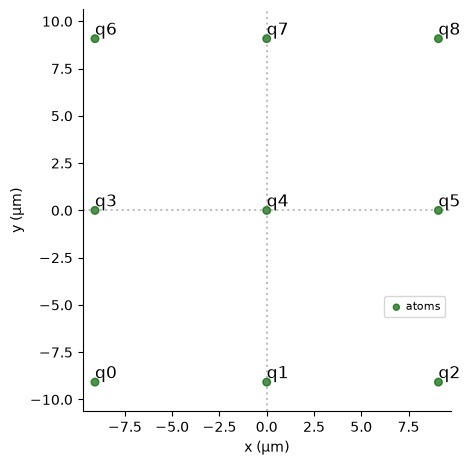


Target checkerboard states:
  010101010
  101010101  (spin-flipped)

As a 2D grid (1 = excited, 0 = ground):
[[0 1 0]
 [1 0 1]
 [0 1 0]]


In [ ]:
device = MockDevice

# Choose the lattice spacing so nearest neighbours lie within the blockade radius.
# This makes simultaneous excitation of neighbours energetically unfavorable.
spacing = device.rydberg_blockade_radius(U)

# Build the square register that defines the atomic positions.
reg = Register.square(L, spacing, prefix="q")
print(f"N = {L*L} atoms, spacing = {spacing:.2f} um, U = {U:.2f} rad/us")
reg.draw()

# Grid indices of each atom, in the SAME order as the measured bitstrings
coords = np.array([reg.qubits[q] for q in reg.qubits])
xs = np.round((coords[:, 0] - coords[:, 0].min()) / spacing).astype(int)
ys = np.round((coords[:, 1] - coords[:, 1].min()) / spacing).astype(int)

stagger_sign = (-1) ** (xs + ys)                                                     # +1 / -1 checkerboard sign per atom

# The two symmetry-related antiferromagnetic ground states on a bipartite square lattice.
patt = (xs + ys) % 2
afm1 = "".join(str(b) for b in patt)                  # one checkerboard
afm2 = "".join(str(1 - b) for b in patt)              # its spin-flipped partner
print(f"\nTarget checkerboard states:\n  {afm1}\n  {afm2}  (spin-flipped)")
print("\nAs a 2D grid (1 = excited, 0 = ground):")
print(patt.reshape(L, L))

## 4. The pulse sequence

At negative detuning, the ground state favours low excitation number, so the system begins in a disordered paramagnet. As the detuning is swept upward, excitation becomes more favourable, but the blockade prevents neighbouring atoms from all flipping at once. That frustration drives the system toward an alternating checkerboard pattern.

The crucial adiabatic idea is that the drive stays on while the detuning crosses the transition. That allows the many-body state to evolve smoothly rather than being forced abruptly into a classical configuration.


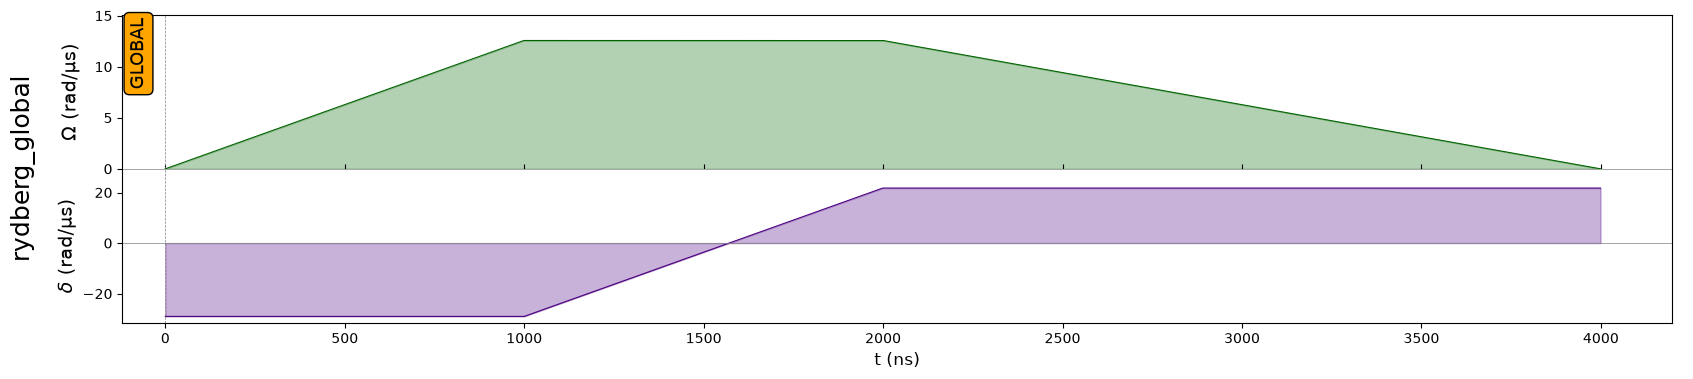

In [ ]:
Delta1_max = central_normalized_interaction(L) / 2 * U                 # pick a detuning well inside the ordered phase

seq_demo = build_afm_sequence(Omega_max, t_ramp, t_hold, t_fall,
                              Delta0, Delta1_max, device, reg)         # build the full adiabatic sweep

seq_demo.draw()                                                        # illustrate and validate visually

## 5. Sanity check — did order form?

Before making the main figures, it is useful to confirm that the final state really carries strong antiferromagnetic order. The staggered magnetisation should be clearly above zero, while the structure factor should show the same trend through correlations.


In [ ]:
cfg = QutipConfig(observables=(BitStrings(evaluation_times=[1.0], num_shots=num_shots),))    # onfigure the simulation
res = pulser.backends.QutipBackendV2(seq_demo, config=cfg).run()

counts = res.get_result("bitstrings", res.get_result_times("bitstrings")[-1])                # read final snapshot only

print(f"final staggered magnetisation = {staggered_magnetisation(counts, L):.3f}")
print(f"final structure factor        = {af_structure_factor(counts, L):.4f}")

final staggered magnetisation = 0.893
final structure factor        = 0.0822


## 6. Graph 1 — order growing *in time* during one sweep

This figure shows the transition dynamically.

Instead of measuring only the end state, we sample the system at many points during a single sweep. The result is a time-resolved picture of symmetry breaking: the staggered magnetisation starts near zero, then rises as the detuning crosses the transition and the checkerboard order stabilises.

The structure factor tracks the same physical process but with more noise.


In [ ]:
eval_times = np.arange(0.0, 1.01, 0.02)                                                             # normalized time points from start to end
                                                                                                    # 0 = start of sweep, 1 = end
# Build the sequence and run the simulation
seq_time = build_afm_sequence(Omega_max, t_ramp, t_hold, t_fall,
                              Delta0, Delta1_max, device, reg)
cfg_time = QutipConfig(observables=(BitStrings(evaluation_times=eval_times, num_shots=num_shots),))
res_time = pulser.backends.QutipBackendV2(seq_time, config=cfg_time).run()

# Analyze the results and compute order parameters at each time point 
T_total = seq_time.get_duration()
times_ns, m_time, s_time = [], [], []

# For each time point, find the corresponding bitstring snapsot, staggered magnetisation and structure factor
for t in res_time.get_result_times("bitstrings"):
    c = res_time.get_result("bitstrings", t)
    times_ns.append(t * T_total)
    m_time.append(staggered_magnetisation(c, L))
    s_time.append(af_structure_factor(c, L))

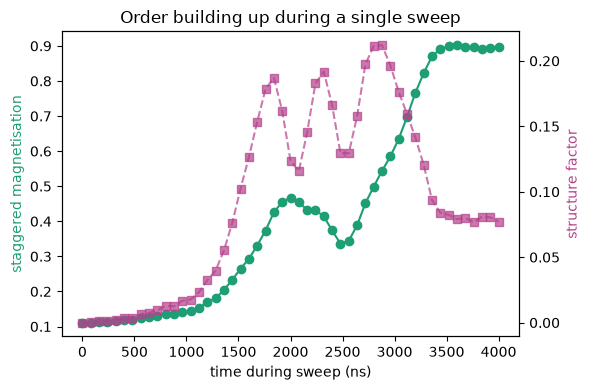

In [ ]:
# Plot the two order parameters against time
fig, ax1 = plt.subplots(figsize=(6, 4))
ax1.plot(times_ns, m_time, "o-", color="#1D9E75", label="staggered magnetisation")
ax1.set_xlabel("time during sweep (ns)")
ax1.set_ylabel("staggered magnetisation", color="#1D9E75")
ax2 = ax1.twinx()
ax2.plot(times_ns, s_time, "s--", color="#B4408B", alpha=0.7, label="structure factor")
ax2.set_ylabel("structure factor", color="#B4408B")
ax1.set_title("Order building up during a single sweep")
fig.tight_layout(); plt.show()

## 7. Graph 2 — Detuning Scan

We repeat the same sweep many times, but each run ends at a different final detuning. That lets us map the final order parameter as a function of the endpoint in parameter space. The transition appears as a flat low-order region on the disordered side and a sharp rise once the endpoint enters the ordered phase.


In [ ]:
delta1_scan = np.linspace(-1.5 * U, 2.5 * U, 15)                                                # range of final detunings to test

m_vals, s_vals = [], []                                                                         # initialize parameter lists

# Conduct the same analysis across the range of detunings
for D1 in delta1_scan:
    seq = build_afm_sequence(Omega_max, t_ramp, t_hold, t_fall, Delta0, D1, device, reg)
    cfg = QutipConfig(observables=(BitStrings(evaluation_times=[1.0], num_shots=num_shots),))
    r = pulser.backends.QutipBackendV2(seq, config=cfg).run()
    c = r.get_result("bitstrings", r.get_result_times("bitstrings")[-1])
    m_vals.append(staggered_magnetisation(c, L))
    s_vals.append(af_structure_factor(c, L))
    print(f"Delta1/U = {D1/U:+.2f}   m_stag = {m_vals[-1]:.3f}   S = {s_vals[-1]:.4f}")

Delta1/U = -1.50   m_stag = 0.112   S = 0.0003
Delta1/U = -1.21   m_stag = 0.111   S = 0.0001
Delta1/U = -0.93   m_stag = 0.112   S = 0.0009
Delta1/U = -0.64   m_stag = 0.118   S = 0.0032
Delta1/U = -0.36   m_stag = 0.145   S = 0.0202
Delta1/U = -0.07   m_stag = 0.240   S = 0.0835
Delta1/U = +0.21   m_stag = 0.422   S = 0.1233
Delta1/U = +0.50   m_stag = 0.827   S = 0.2223
Delta1/U = +0.79   m_stag = 0.954   S = 0.1660
Delta1/U = +1.07   m_stag = 0.966   S = 0.1108
Delta1/U = +1.36   m_stag = 0.973   S = 0.1038
Delta1/U = +1.64   m_stag = 0.960   S = 0.0748
Delta1/U = +1.93   m_stag = 0.933   S = 0.0604
Delta1/U = +2.21   m_stag = 0.899   S = 0.0736
Delta1/U = +2.50   m_stag = 0.870   S = 0.1476


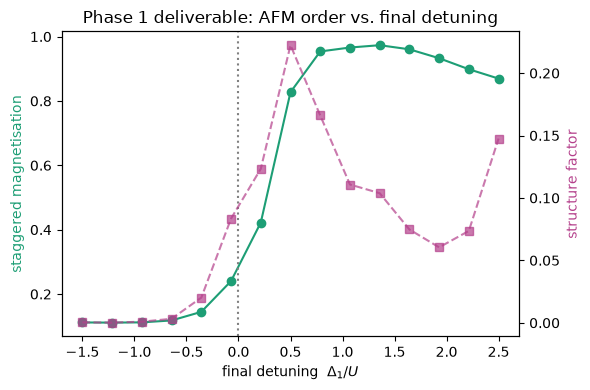

In [ ]:
# Plot the order parameters against the final detuning
fig, ax1 = plt.subplots(figsize=(6, 4))
ax1.plot(delta1_scan / U, m_vals, "o-", color="#1D9E75", label="staggered magnetisation")
ax1.set_xlabel(r"final detuning  $\Delta_1 / U$")
ax1.set_ylabel("staggered magnetisation", color="#1D9E75")
ax1.axvline(0, ls=":", color="gray")
ax2 = ax1.twinx()
ax2.plot(delta1_scan / U, s_vals, "s--", color="#B4408B", alpha=0.7, label="structure factor")
ax2.set_ylabel("structure factor", color="#B4408B")
ax1.set_title("Phase 1 deliverable: AFM order vs. final detuning")
fig.tight_layout(); plt.show()

## 8. Graph 3 — the measured spin patterns (histograms)

Each bar corresponds to one measured bitstring. The bar height is the number of times that configuration was observed. The shading tells you how checkerboard-like that configuration is.

The staggered magnetisation is computed directly from each bitstring by converting bits to spins and projecting onto the checkerboard sign pattern:

\begin{equation}
    m_{\text{stag}} = \frac{1}{N} |\sum_i{\eta_iz_i}|
\end{equation}

where $\eta_i = \pm 1$ is the checkerboard sign and $z_1 = \pm 1$ is the measured spin.

In [ ]:
snapshot_times = np.linspace(0.0, 1.0, 11)                                                              # normalized time points

seq_snap = build_afm_sequence(Omega_max, t_ramp, t_hold, t_fall,
                              Delta0, Delta1_max, device, reg)
cfg_snap = QutipConfig(observables=(BitStrings(evaluation_times=snapshot_times, num_shots=num_shots),))
res_snap = pulser.backends.QutipBackendV2(seq_snap, config=cfg_snap).run()

T_total = seq_snap.get_duration()
snapshots = [(t * T_total, res_snap.get_result("bitstrings", t))
             for t in res_snap.get_result_times("bitstrings")]                                          # snapshots of the bitstrings

print(f"Captured {len(snapshots)} snapshots.")

Captured 11 snapshots.


In [ ]:
def checkerboard_score(bitstring):

    """Score a single measured bitstring by its overlap with the checkerboard pattern.

    This is the per-shot quantity underlying the shading:
    - 0 means the configuration does not resemble the checkerboard mode
    - 1 means a perfect checkerboard configuration
    """

    z = 2 * np.array([int(c) for c in bitstring]) - 1
    return abs(np.dot(stagger_sign, z)) / len(z)

def plot_snapshot_histogram(time_ns, counts, top_n=12):

    """Plot the most frequent bitstrings at one time slice.

    The bar height is the number of occurrences.
    The bar shade is determined by the checkerboard overlap.
    """

    items = sorted(counts.items(), key=lambda kv: -kv[1])[:top_n]
    labels = [k for k, _ in items]
    values = [v for _, v in items]
    plt.figure(figsize=(9, 3.5))
    for i, (lab, val) in enumerate(zip(labels, values)):
        shade = 0.25 + 0.75 * checkerboard_score(lab)      # darker = more ordered
        plt.bar(i, val, color=plt.cm.RdPu(shade))
    plt.xticks(range(len(labels)), labels, rotation="vertical")
    plt.ylabel("counts")
    plt.title(f"Snapshot at t = {time_ns:.0f} ns   (darker = more checkerboard-like)")
    plt.tight_layout(); plt.show()

def show_snapshot(index):
    time_ns, counts = snapshots[index]
    plot_snapshot_histogram(time_ns, counts)

# Introduce interactive slider
interact(show_snapshot,
         index=IntSlider(min=0, max=len(snapshots) - 1, step=1,
                         value=len(snapshots) - 1, description="snapshot"));

interactive(children=(IntSlider(value=10, description='snapshot', max=10), Output()), _dom_classes=('widget-in…

# 9. Cloud extension with more atoms 

The local exact simulation is useful for transparency and correctness, but larger lattices require a more approximate backend. The cloud-backed matrix product state emulation lets us increase the number of atoms while still keeping the simulation tractable. This is the right place to show:

* the same detuning scan on a larger lattice,
* a convergence check using two bond dimensions,
* a larger histogram that reveals checkerboard structure.

In [ ]:


from pulser_pasqal import PasqalCloud
credentials_file = "credentials.example.yaml"         # this part has to be changed to include credentials of the participants 
connection = load_pasqal_config(credentials_file)
connection = PasqalCloud(
    username=connection['username'],                  # Your username or email address for the Pasqal Cloud Platform
    project_id=connection['project_id'],              # The ID of the project associated to your account
    password=connection['password'],                  # The password for your Pasqal Cloud Platform account
)


In [ ]:
# ============================================================
#  CLOUD RUN — CELL A: submit jobs (does NOT wait for results)
# ============================================================

# --- larger register ---
L_cloud = 5                                                                      # 25 atoms; raise to 6, 7, ...
reg_cloud = Register.square(L_cloud, spacing, prefix="q")
print(f"Cloud run: N = {L_cloud * L_cloud} atoms")

# checkerboard reference for the histogram at the new size
coords_c = np.array([reg_cloud.qubits[q] for q in reg_cloud.qubits])
xs_c = np.round((coords_c[:, 0] - coords_c[:, 0].min()) / spacing).astype(int)
ys_c = np.round((coords_c[:, 1] - coords_c[:, 1].min()) / spacing).astype(int)
stagger_sign_c = (-1) ** (xs_c + ys_c)

# --- cloud settings ---
dt = 10
num_shots_cloud = 1000
chi_main = 50                                                                    # bond dim for the full scan
chi_check = 100                                                                  # second bond dim, convergence only

delta1_scan_cloud = np.linspace(-1.5 * U, 2.5 * U, 9)
eval_times_cloud = np.arange(0.0, 1.01, 0.05)
check_idx = [3, 4, 5]                                                            # transition points for the convergence check

# --- submit helper ---
def submit(seq, evt, chi):
    cfg = pulser.backend.EmulationConfig(
        observables=(BitStrings(evaluation_times=evt, num_shots=num_shots_cloud),),
        dt=dt, max_bond_dim=chi)
    return pulser.backends.EmuMPSBackend(seq, config=cfg, connection=connection).run()

# --- submit everything (returns immediately; jobs run on the cloud) ---
scan_handles = []                                                                # (Delta1, handle) at chi_main, full scan
for D1 in delta1_scan_cloud:
    seq = build_afm_sequence(Omega_max, t_ramp, t_hold, t_fall, Delta0, D1, device, reg_cloud)
    h = submit(seq, [1.0], chi_main)
    print(f"Submitted {h.batch_id}  (scan, Delta1/U = {D1/U:+.2f})")
    scan_handles.append((D1, h))

check_handles = []                                                               # (Delta1, handle) at chi_check, transition points only
for i in check_idx:
    D1 = delta1_scan_cloud[i]
    seq = build_afm_sequence(Omega_max, t_ramp, t_hold, t_fall, Delta0, D1, device, reg_cloud)
    h = submit(seq, [1.0], chi_check)
    print(f"Submitted {h.batch_id}  (check, Delta1/U = {D1/U:+.2f})")
    check_handles.append((D1, h))

seq_t = build_afm_sequence(Omega_max, t_ramp, t_hold, t_fall, Delta0, Delta1_max, device, reg_cloud)
time_handle = submit(seq_t, eval_times_cloud, chi_main)
print(f"Submitted {time_handle.batch_id}  (time-sweep)")

print(f"\n{len(scan_handles) + len(check_handles) + 1} jobs submitted. "
      f"Check the Pasqal Cloud dashboard; run Cell B once they show DONE.")

Cloud run: N = 25 atoms
Submitted aed45998-04d7-4298-a48d-8f986e64b49c  (scan, Delta1/U = -1.50)
Submitted b33a8e98-30f6-4fd0-af74-065a4246f50d  (scan, Delta1/U = -1.00)
Submitted 89b444bc-9751-4af9-87e8-07821d68149b  (scan, Delta1/U = -0.50)
Submitted a50aa58e-996d-4199-a667-be605c16f5a0  (scan, Delta1/U = +0.00)
Submitted ccb6c6d2-57d2-4055-a1da-f2519d2ca547  (scan, Delta1/U = +0.50)
Submitted 82b3195a-3f44-44f1-b8a9-5bba7dc0a1b3  (scan, Delta1/U = +1.00)
Submitted 9583f09d-cc7d-4a19-8d9a-04d056b7eb4f  (scan, Delta1/U = +1.50)
Submitted 83998a68-44b8-4527-b0ba-0d6de398eb21  (scan, Delta1/U = +2.00)
Submitted af2cc457-41db-4865-ab23-cba7fbcfacff  (scan, Delta1/U = +2.50)
Submitted a2b8989f-d3d0-46e5-b059-9000c4d2957f  (check, Delta1/U = +0.00)
Submitted 3bf875e3-8bab-45fb-815f-52fc85da2aac  (check, Delta1/U = +0.50)
Submitted 7217e564-0797-4b57-9638-abdab51d9840  (check, Delta1/U = +1.00)
Submitted 83d2d257-8252-4766-98a9-46e93173418a  (time-sweep)

13 jobs submitted. Check the Pasqal

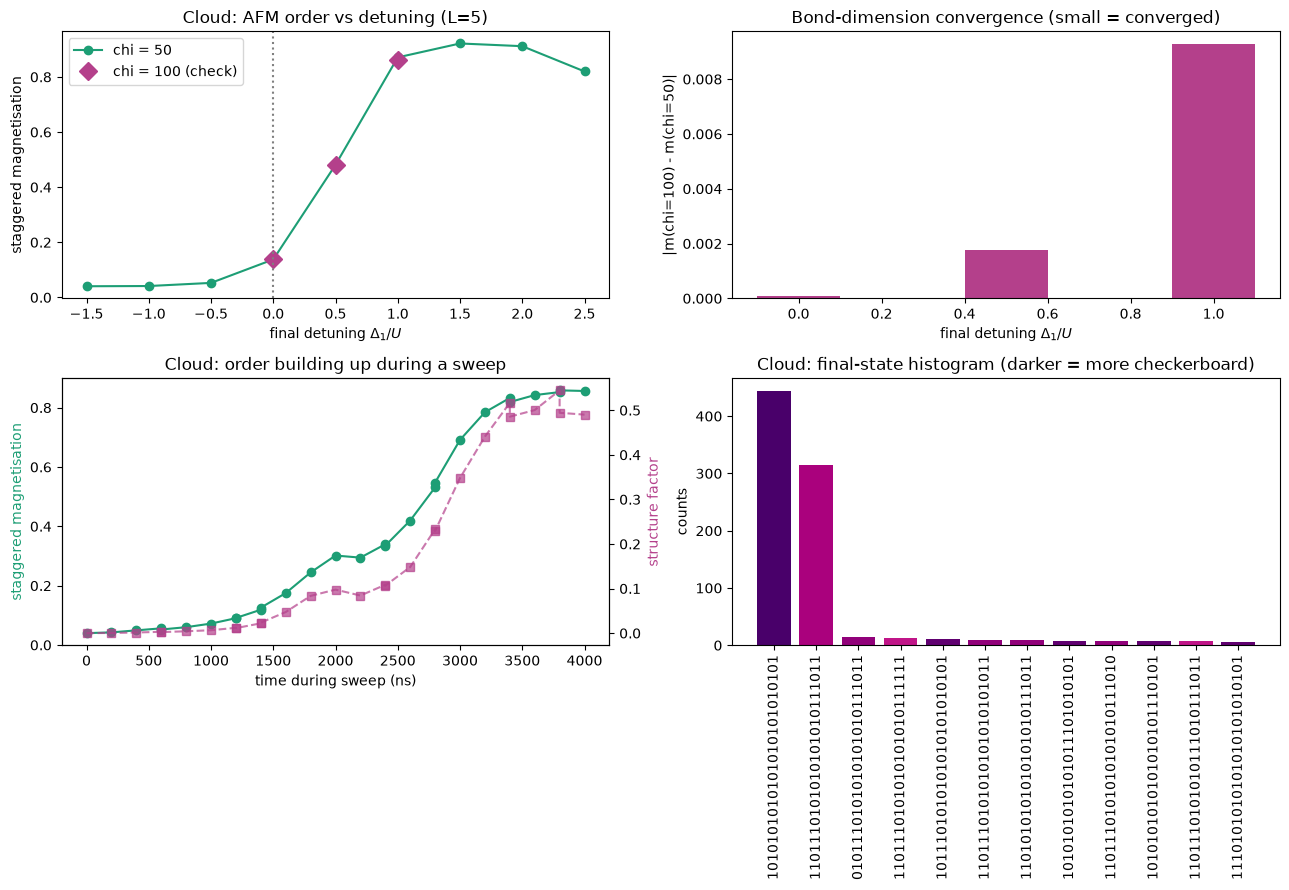

In [ ]:
# ============================================================
#  CLOUD RUN — CELL B: retrieve results and plot
#  Run this only once the jobs show DONE on the cloud dashboard.
# ============================================================

# quick guard: check everything is actually done before reading
all_handles = [h for _, h in scan_handles] + [h for _, h in check_handles] + [time_handle]
statuses = [str(h.get_batch_status()) for h in all_handles]
if not all(s == "BatchStatus.DONE" for s in statuses):
    print("Not all jobs are DONE yet. Current statuses:")
    for h, s in zip(all_handles, statuses):
        print(f"  {h.batch_id}: {s}")
    raise SystemExit("Wait until all jobs are DONE, then re-run this cell.")

# ---------- collect results ----------
m_scan, s_scan = [], []
for D1, h in scan_handles:
    counts = h[-1].get_result("bitstrings", 1.0)
    m_scan.append(staggered_magnetisation(counts, L_cloud))
    s_scan.append(af_structure_factor(counts, L_cloud))

m_check = []
for D1, h in check_handles:
    counts = h[-1].get_result("bitstrings", 1.0)
    m_check.append(staggered_magnetisation(counts, L_cloud))

T_cloud = seq_t.get_duration()
times_c, m_time_c, s_time_c = [], [], []
for t in time_handle[-1].get_result_times("bitstrings"):
    c = time_handle[-1].get_result("bitstrings", t)
    times_c.append(t * T_cloud)
    m_time_c.append(staggered_magnetisation(c, L_cloud))
    s_time_c.append(af_structure_factor(c, L_cloud))

final_counts = scan_handles[-1][1][-1].get_result("bitstrings", 1.0)

# ---------- display everything together ----------
fig, ax = plt.subplots(2, 2, figsize=(13, 9))

# (a) order vs detuning, with convergence-check points overlaid
ax[0, 0].plot(delta1_scan_cloud / U, m_scan, "o-", color="#1D9E75", label=f"chi = {chi_main}")
ax[0, 0].plot([delta1_scan_cloud[i] / U for i in check_idx], m_check, "D",
              color="#B4408B", markersize=9, label=f"chi = {chi_check} (check)")
ax[0, 0].axvline(0, ls=":", color="gray")
ax[0, 0].set_xlabel(r"final detuning $\Delta_1 / U$")
ax[0, 0].set_ylabel("staggered magnetisation")
ax[0, 0].set_title(f"Cloud: AFM order vs detuning (L={L_cloud})")
ax[0, 0].legend()

# (b) convergence: difference at the checked points (small = converged)
diffs = [abs(m_check[j] - m_scan[i]) for j, i in enumerate(check_idx)]
ax[0, 1].bar([delta1_scan_cloud[i] / U for i in check_idx], diffs, width=0.2, color="#B4408B")
ax[0, 1].set_xlabel(r"final detuning $\Delta_1 / U$")
ax[0, 1].set_ylabel(f"|m(chi={chi_check}) - m(chi={chi_main})|")
ax[0, 1].set_title("Bond-dimension convergence (small = converged)")

# (c) order building up in time
ax[1, 0].plot(times_c, m_time_c, "o-", color="#1D9E75")
ax1b = ax[1, 0].twinx()
ax1b.plot(times_c, s_time_c, "s--", color="#B4408B", alpha=0.7)
ax[1, 0].set_xlabel("time during sweep (ns)")
ax[1, 0].set_ylabel("staggered magnetisation", color="#1D9E75")
ax1b.set_ylabel("structure factor", color="#B4408B")
ax[1, 0].set_title("Cloud: order building up during a sweep")

# (d) final-state histogram, shaded by checkerboard-likeness
items = sorted(final_counts.items(), key=lambda kv: -kv[1])[:12]
for i, (lab, val) in enumerate(items):
    z = 2 * np.array([int(cc) for cc in lab]) - 1
    shade = 0.25 + 0.75 * abs(np.dot(stagger_sign_c, z)) / len(z)
    ax[1, 1].bar(i, val, color=plt.cm.RdPu(shade))
ax[1, 1].set_xticks(range(len(items)))
ax[1, 1].set_xticklabels([k for k, _ in items], rotation="vertical")
ax[1, 1].set_ylabel("counts")
ax[1, 1].set_title("Cloud: final-state histogram (darker = more checkerboard)")

fig.tight_layout()
plt.show()

## Summary

* **Graph 1 (order vs. time):** the antiferromagnet forms as the sweep crosses the transition.
* **Graph 2 (order vs. detuning):** the Phase 1 deliverable — maps the quantum phase transition; order
  is flat on the disordered side and rises where the sweep ends in the ordered phase.
* **Graph 3 (histograms):** the raw measured spin patterns, shaded by how checkerboard-like they are.

## Next step
Phase 2 can replace the square lattice with the triangular geometry relevant to TmMgGaO4 and reuse the same logic: build the Hamiltonian, define observables, validate convergence, and connect the simulated response to a real material platform.
